# 4 Train and Analyze

This notebook is designed to run Cross-Validation and analyse the logits

## 4.1 Imports

In [1]:
from pathlib import Path
import os
from collections import Counter

from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import torch

import utilities as u

pd.options.display.max_rows = 1000
print(Path('..').absolute())

c:\Users\User\Askar\Thesis\..


## 4.2 Cross-Valiation

In [2]:
def run_cv():

    wrapper = u.TrainingWrapper(logs_dir='GNNLogs')
    wrapper.set_settings(verbose=1, device='cuda')
    wrapper.initialize_dataset(use_folds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], reduction=1, dir_samples='Files/Residues_Only_25_8')

    counter = 0

    for i in range(5):

        counter += 1

        print(f'-------------------{counter}--------------------')
        
        train_folds = [j for j in range(10) if not i * 2 <= j < (i + 1) * 2]
        valid_folds = [i * 2, i * 2 + 1]

        wrapper.set_settings(verbose=1, device='cuda', epochs=20, show_progress=True)
        wrapper.split_dataset(train_folds=train_folds, valid_folds=valid_folds, test_folds=valid_folds)
        wrapper.initialize_loaders(train_loader_kwargs={'batch_size': 256, 'shuffle': True},
                                    valid_loader_kwargs={'batch_size': 256, 'shuffle': True},
                                    test_loader_kwargs={'batch_size': 256, 'shuffle': True})
        wrapper.initialize_model(
                                encoder_hidden_dim=16,
                                encoder_depth=1,
                                gnn_hidden_dim=256,
                                gnn_depth=3,
                                gnn_activation='leakyrelu',
                                dense_dim=256,
                                dense_depth=3,
                                dense_activation='leakyrelu',
                                dropout=0.2,
                                batch_norm=True,
                                seed=42
                                )
        wrapper.initialize_optimizer(lr=1e-4)
        wrapper.initialize_scheduler(step_size=1, gamma=0.8)
        wrapper.initialize_loss_function(pos_weight=10)

        try:
            wrapper.train(save_best_logits=f'CV/{i}.csv')
        except BaseException as e:
            print('ERROR: ', e)
            continue

In [3]:
if os.path.isdir('CV') and not (set(os.listdir('CV')) - {'0.csv', '1.csv', '2.csv', '3.csv', '4.csv'}):
    cv_already_run = True
else:
    cv_already_run = False

if not cv_already_run:
    run_cv()

## 4.3 CV Logs

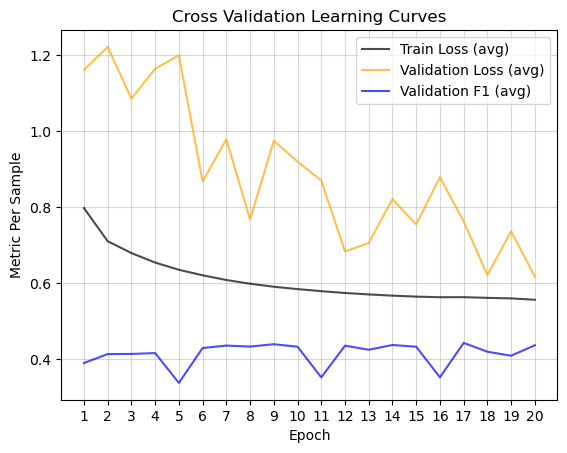

In [4]:
if not os.path.isfile('cv_logs.csv'):

    cv_logs = []
    for file in os.listdir('GNNLogs'):
        if file[-3:] != 'csv':
            continue
        cv_logs.append(pd.read_csv(os.path.join('GNNLogs', file), index_col=0))
    cv_logs = pd.concat(cv_logs)
    cv_logs = u.subsample_logs(cv_logs, {'epochs': [20], 'reduction': [1], 'use_folds': [str(list(range(10)))]})
    cv_logs.to_csv('cv_logs.csv')

else:
    cv_logs = pd.read_csv('cv_logs.csv', index_col=0)

u.plot_cv_logs('cv_logs.csv', save=None);

## 4.4 Logits Collection

### 4.4.1 Getting bulk logits

In [5]:
bulk_cv_logits = []
for i in tqdm(range(5), desc='Collective bulk logits...'):
    bulk_cv_logits.append(
        pd.read_csv(f'CV/{i}.csv')
    )
bulk_cv_logits = pd.concat(bulk_cv_logits)
bulk_cv_logits

Collective bulk logits...: 100%|██████████| 5/5 [00:00<00:00,  9.97it/s]


,logits,labels,entries
0,-0.383756,0.0,8301
1,-1.008867,0.0,6665
2,-5.219006,0.0,6545
3,-2.230970,0.0,4330
4,-2.447765,0.0,5061
...,...,...,...
805224,-2.738338,0.0,1624
805225,-3.095907,0.0,12263
805226,-2.446383,0.0,26
805227,-2.897617,0.0,2929


### 4.4.2 Analyze logits

u.analyse_logits computes and returns bulk metrics table, but it also computes protein-level metrics and save them as csv-files to the Metrics folder

In [6]:
all_metrics = u.analyse_logits(bulk_cv_logits)

In [7]:
print('Bulk Metrics')
display(all_metrics)

Bulk Metrics


,f1,auc,ap,acc,bacc,prec,rec,jac,n
group,,,,,,,,,
all,0.428136,0.896119,0.517537,0.873277,0.806107,0.303081,0.728885,0.272375,3930738
SCOPe: l,0.457375,0.901219,0.534972,0.869668,0.818871,0.327215,0.759483,0.296491,375801
SCOPe: d,0.475001,0.914738,0.604936,0.877838,0.831027,0.342161,0.776446,0.311476,940074
SCOPe: c,0.389642,0.883125,0.420837,0.872835,0.786103,0.271818,0.687764,0.241960,1337524
SCOPe: -,0.317340,0.865510,0.322722,0.864906,0.768559,0.208678,0.662116,0.188594,446342
SCOPe: a,0.424527,0.884279,0.458418,0.873181,0.786831,0.307198,0.686865,0.269460,258565
SCOPe: e,0.386225,0.883849,0.419935,0.917600,0.774285,0.280915,0.617841,0.239330,202232
SCOPe: b,0.536068,0.916279,0.707768,0.839989,0.835077,0.396159,0.828755,0.366184,287824
SCOPe: g,0.327485,0.847927,0.312274,0.880805,0.732761,0.230088,0.567863,0.195804,25085


### 4.4.3 Get Protein-Level Metrics and Classes

In [8]:
per_entry_df = u.read_per_entry_metrics(per_entry_path='Metrics/per_entry.csv')
display(per_entry_df)

,id,f1,auc,ap,acc,bacc,prec,rec,jac,n,...,ec_class,ec_subclass,organism,reign,size_class,uniprot,ligand,scope_class_desc,ec_class_desc,reign_desc
0,3ch6_2,0.289655,0.835837,0.185030,0.810313,0.720415,0.189189,0.617647,0.169355,543,...,1,1.1,Homo sapiens,Eukaryota,500-700,P28845,311,Artifacts,Oxidoreductases,Eukaryota
1,2uwd_1,0.569106,0.884528,0.611930,0.745192,0.834948,0.402299,0.972222,0.397727,208,...,3,3.6,Homo sapiens,Eukaryota,200-300,P07900,2GG,Helices + Sheets\n(segregated),Hydrolases,Eukaryota
2,2r8o_1,0.379310,0.913497,0.347781,0.918736,0.776838,0.272727,0.622642,0.234043,1329,...,2,2.2,Escherichia coli,Bacteria,>1000,P27302,T5X,Helices + Sheets\n(interleaved),Transferases,Bacteria
3,2bel_4,0.189189,0.752706,0.105883,0.880120,0.648758,0.123894,0.400000,0.104478,1001,...,1,1.1,Homo sapiens,Eukaryota,>1000,P28845,CBO,Artifacts,Oxidoreductases,Eukaryota
4,2g0n_2,0.454545,0.897868,0.414714,0.798319,0.848064,0.303030,0.909091,0.294118,357,...,3,3.6,Homo sapiens,Eukaryota,300-400,P60763,GDP,Artifacts,Hydrolases,Eukaryota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7953,2cbs_1,0.568627,0.910280,0.756710,0.678832,0.782399,0.402778,0.966667,0.397260,137,...,-,-,Homo sapiens,Eukaryota,100-200,P29373,R13,Beta-Sheets,Unknown,Eukaryota
7954,4fe6_1,0.733333,0.964531,0.926597,0.838384,0.879577,0.594595,0.956522,0.578947,99,...,2,2.7,Human immunodeficiency virus,Viruses,0-100,P03367,0TQ,Beta-Sheets,Transferases,Viruses
7955,4elb_1,0.644444,0.904811,0.780773,0.807229,0.791735,0.557692,0.763158,0.475410,166,...,1,1.5,Bacillus anthracis,Bacteria,100-200,Q81R22,34S,Artifacts,Oxidoreductases,Bacteria
7956,1db5_1,0.555556,0.885883,0.785966,0.612903,0.731183,0.389610,0.967742,0.384615,124,...,3,3.1,Homo sapiens,Eukaryota,100-200,P14555,6IN,Alpha-Helices,Hydrolases,Eukaryota


## 4.5 Visualize Protein-Level Metrics

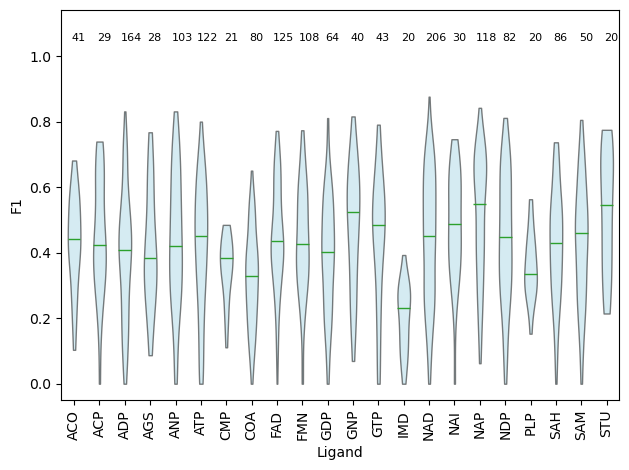

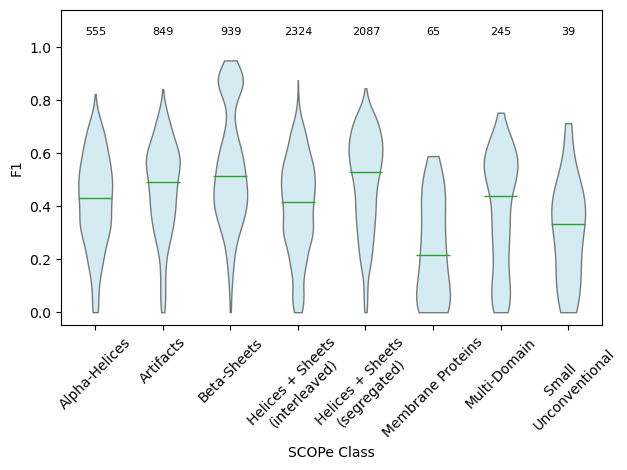

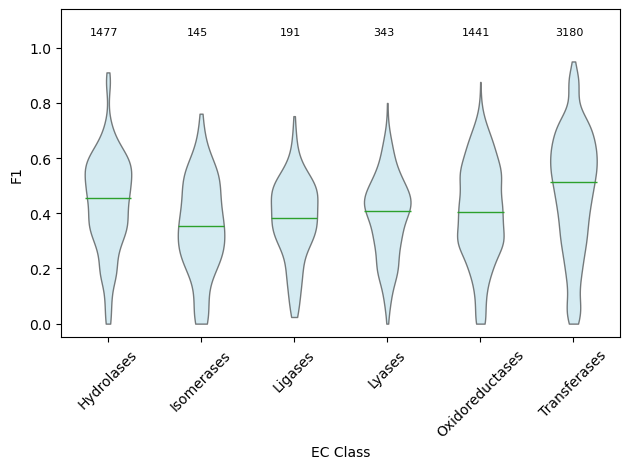

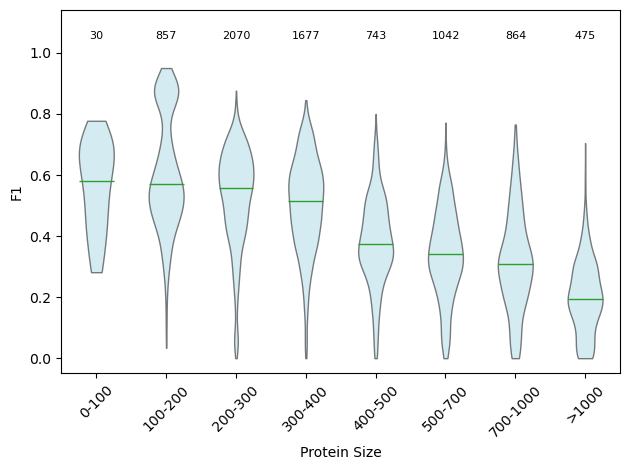

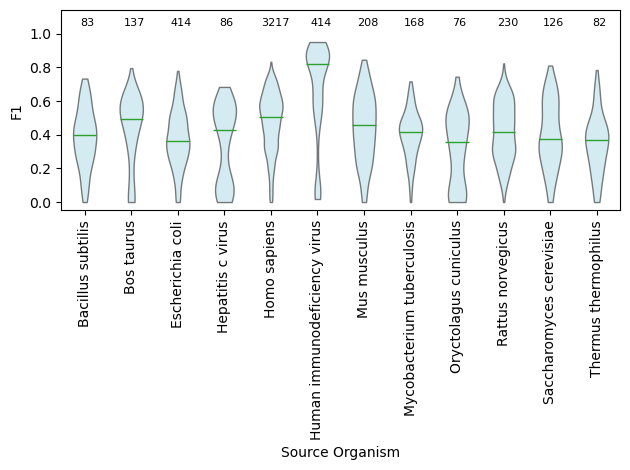

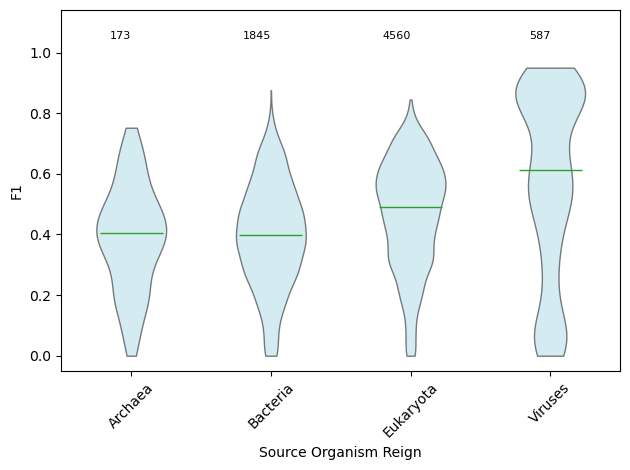

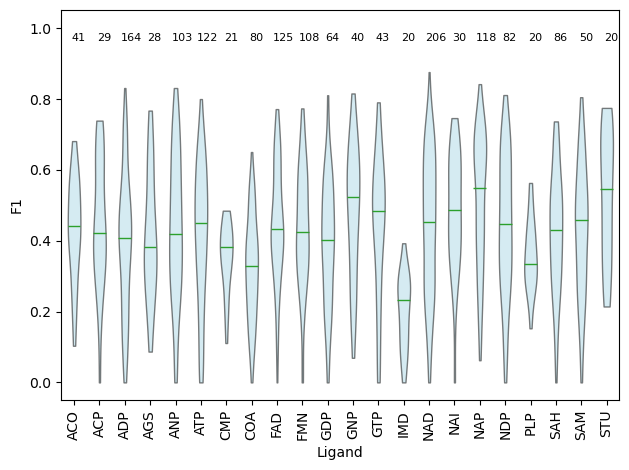

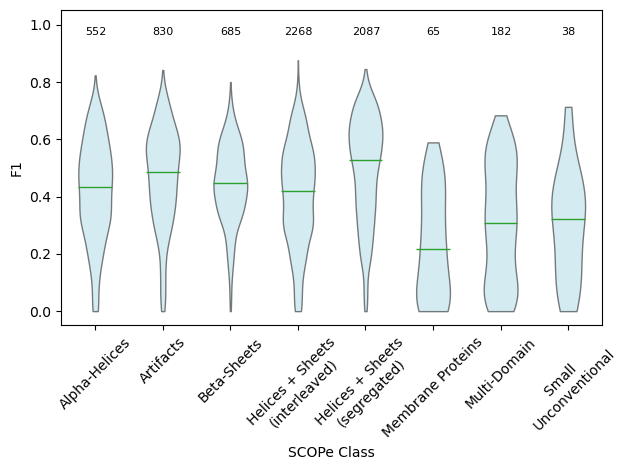

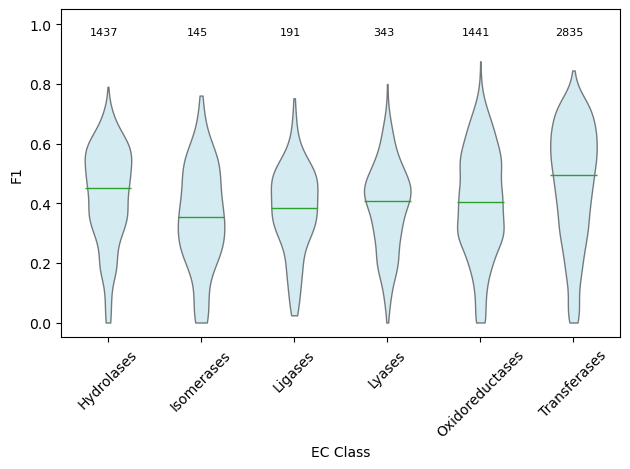

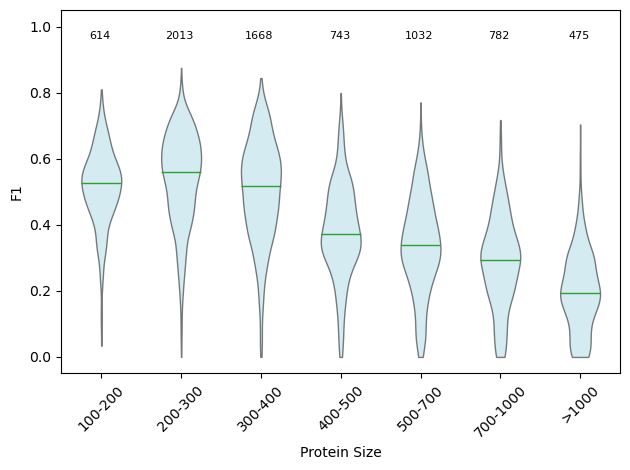

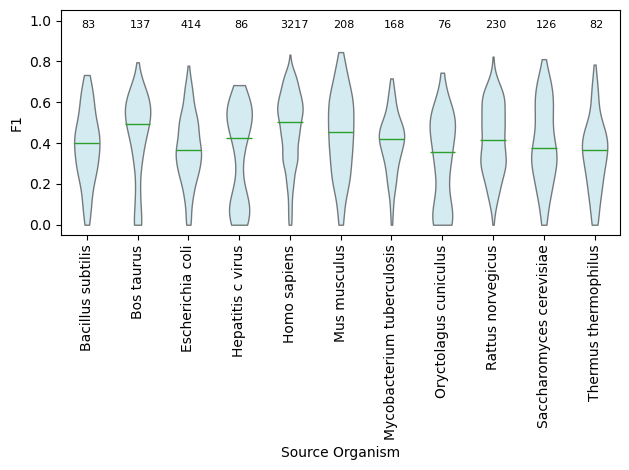

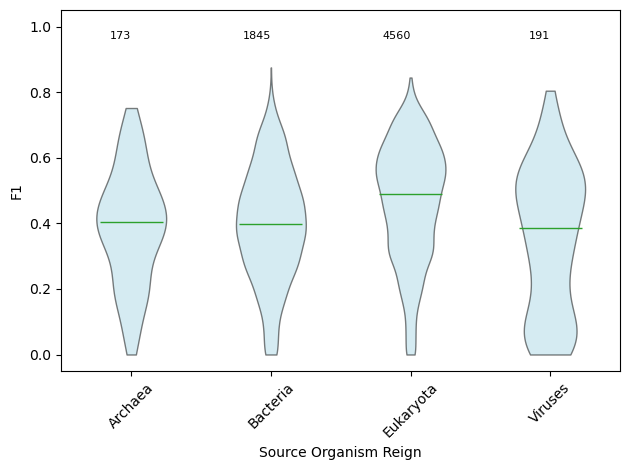

In [9]:
no_hiv_df = per_entry_df.loc[per_entry_df['organism'] != 'Human immunodeficiency virus'].copy()
METRIC = 'f1'

u.plot_stats(per_entry_df, group='ligand',            limit=20, metric=METRIC, rot=90, save='Images/ligand_f1_new.pdf',         title=''    )
u.plot_stats(per_entry_df, group='scope_class_desc',  limit=30, metric=METRIC, rot=45, save='Images/scope_f1_new.pdf',          title=''    )
u.plot_stats(per_entry_df, group='ec_class_desc',     limit=50, metric=METRIC, rot=45, save='Images/ec_f1_new.pdf' ,            title=''    )
u.plot_stats(per_entry_df, group='size_class',        limit=30, metric=METRIC, rot=45, save='Images/size_f1_new.pdf' ,          title=''    )
u.plot_stats(per_entry_df, group='organism',          limit=70, metric=METRIC, rot=90, save='Images/org_f1_new.pdf'  ,          title=''    )
u.plot_stats(per_entry_df, group='reign_desc',        limit=70, metric=METRIC, rot=45, save='Images/reign_f1_new.pdf',          title=''    )

u.plot_stats(no_hiv_df,    group='ligand',            limit=20, metric=METRIC, rot=90, save='Images/ligand_f1_no_hiv_new.pdf', title=''   )
u.plot_stats(no_hiv_df,    group='scope_class_desc',  limit=30, metric=METRIC, rot=45, save='Images/scope_f1_no_hiv_new.pdf',  title=''   )
u.plot_stats(no_hiv_df,    group='ec_class_desc',     limit=50, metric=METRIC, rot=45, save='Images/ec_f1_no_hiv_new.pdf',     title=''   )
u.plot_stats(no_hiv_df,    group='size_class',        limit=30, metric=METRIC, rot=45, save='Images/size_f1_no_hiv_new.pdf',   title=''   )
u.plot_stats(no_hiv_df,    group='organism',          limit=70, metric=METRIC, rot=90, save='Images/org_f1_no_hiv_new.pdf',    title=''   )
u.plot_stats(no_hiv_df,    group='reign_desc',        limit=70, metric=METRIC, rot=45, save='Images/reign_f1_no_hiv_new.pdf',  title=''   );


## 4.6 HIV Cluster

In [10]:
hiv_cluster = per_entry_df.loc[
                                (per_entry_df['organism'] == 'Human immunodeficiency virus')]

hiv_cluster_props = {
    'group': 'HIV cluster',
    'f1': float(hiv_cluster['f1'].mean()),
    'length': float(hiv_cluster['n'].mean()),
    'length SD': float(hiv_cluster['n'].std()),
    'sample per SCOPe subclasses': len(hiv_cluster) / len(hiv_cluster['scope_subclass'].unique()),
    'samples per EC classes': len(hiv_cluster) / len(hiv_cluster['ec_class'].unique()),
    'samples per EC subclasses': len(hiv_cluster) / len(hiv_cluster['ec_subclass'].unique()),
    'Ligands per Uniprot': len(hiv_cluster['ligand'].unique()) / len(hiv_cluster['uniprot'].unique()),
    'Transferases': hiv_cluster['ec_class_desc'].value_counts()['Transferases'] / len(hiv_cluster)
}

com_cluster_props = {
    'group': 'Entire Data',
    'f1': float(per_entry_df['f1'].mean()),
    'length': float(per_entry_df['n'].mean()),
    'length SD': float(per_entry_df['n'].std()),
    'sample per SCOPe subclasses': len(per_entry_df) / len(per_entry_df['scope_subclass'].unique()),
    'samples per EC classes': len(per_entry_df) / len(per_entry_df['ec_class'].unique()),
    'samples per EC subclasses': len(per_entry_df) / len(per_entry_df['ec_subclass'].unique()),
    'Ligands per Uniprot': len(per_entry_df['ligand'].unique()) / len(per_entry_df['uniprot'].unique()),
    'Transferases': per_entry_df['ec_class_desc'].value_counts()['Transferases'] / len(per_entry_df)
}

comparison_table = pd.DataFrame([com_cluster_props, hiv_cluster_props]).transpose()
display(comparison_table)

,0,1
group,Entire Data,HIV cluster
f1,0.440012,0.667708
length,493.935411,368.557971
length SD,389.577823,299.42239
sample per SCOPe subclasses,31.832,59.142857
samples per EC classes,994.75,138.0
samples per EC subclasses,130.459016,103.5
Ligands per Uniprot,1.810295,7.6
Transferases,0.399598,0.833333


## 4.7 Statistical Analysis

- Kruskal-Wallis
- Dunn's Post-Hoc
- Cliff's Deltas

In [11]:
combined_results = {}
GROUPS = ['scope_class_desc', 'ec_class_desc', 'size_class', 'reign', 'organism', 'ligand']
LIMITS = [30, 30, 0, 0, 50, 30]
for i, group in tqdm(enumerate(GROUPS), total=len(GROUPS)):

    counts = Counter(no_hiv_df[group].tolist())
    enough = [c[0] for c in counts.items() if (c[1] >= LIMITS[i]) and(c[0] not in ['Unknown', '-']) and isinstance(c[0], str)]
    combined_results.update(
        {group: u.stats_analysis(no_hiv_df.loc[no_hiv_df[group].isin(enough)], group=group)}
        )

100%|██████████| 6/6 [00:10<00:00,  1.82s/it]


## 4.8 Visualize Dunn's Matrices

,classification,groups,statistics,p-value
0,scope_class_desc,8,454.996721,3.752879e-94
1,ec_class_desc,6,225.303231,1.085838e-46
2,size_class,8,2789.590507,0.000000e+00
3,reign,4,262.282106,1.442564e-56
4,organism,18,297.866709,3.101639e-53
5,ligand,16,68.416601,8.538673e-09


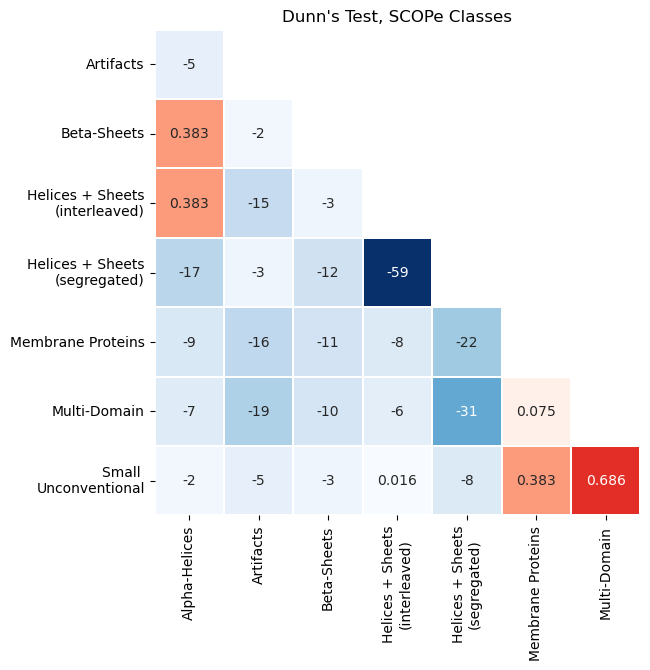

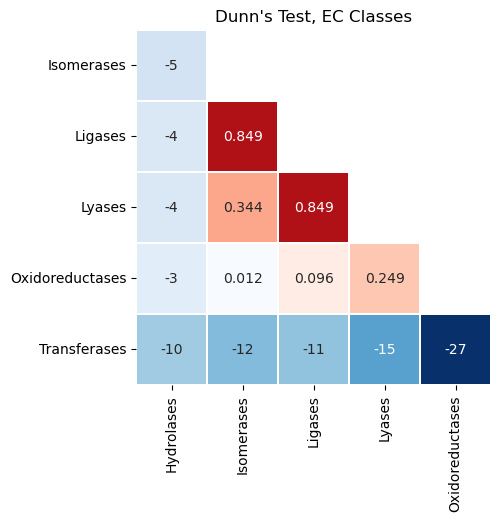

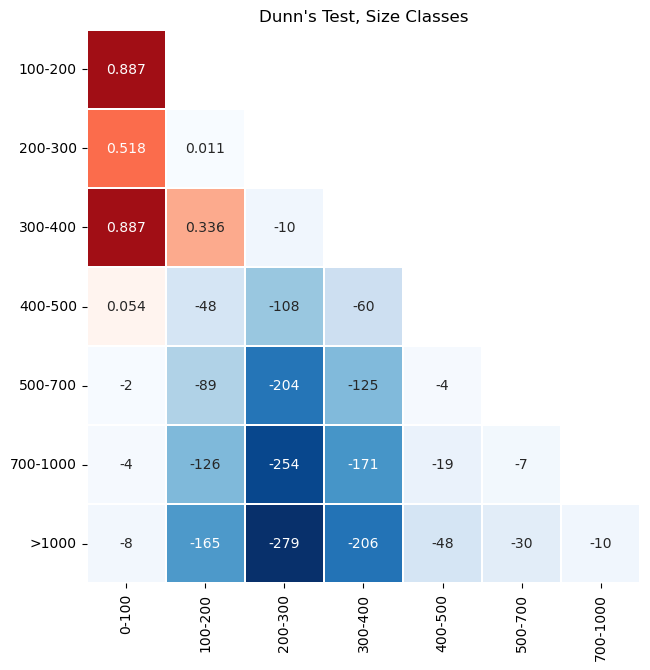

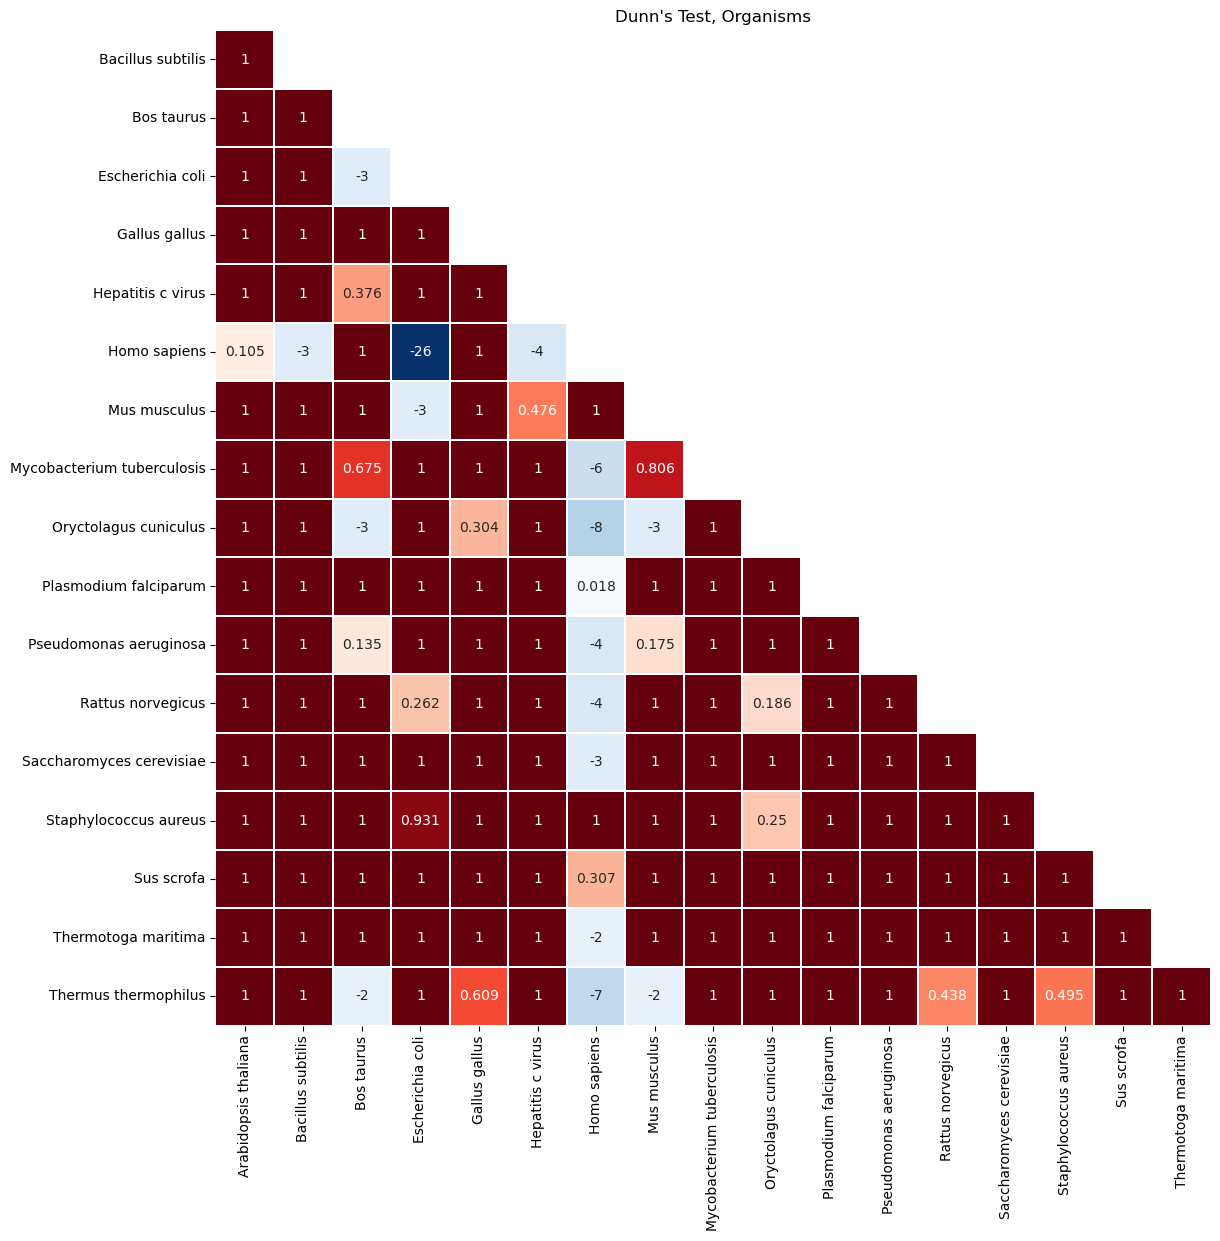

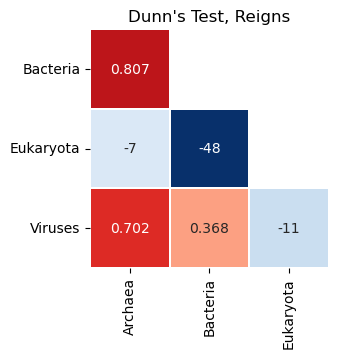

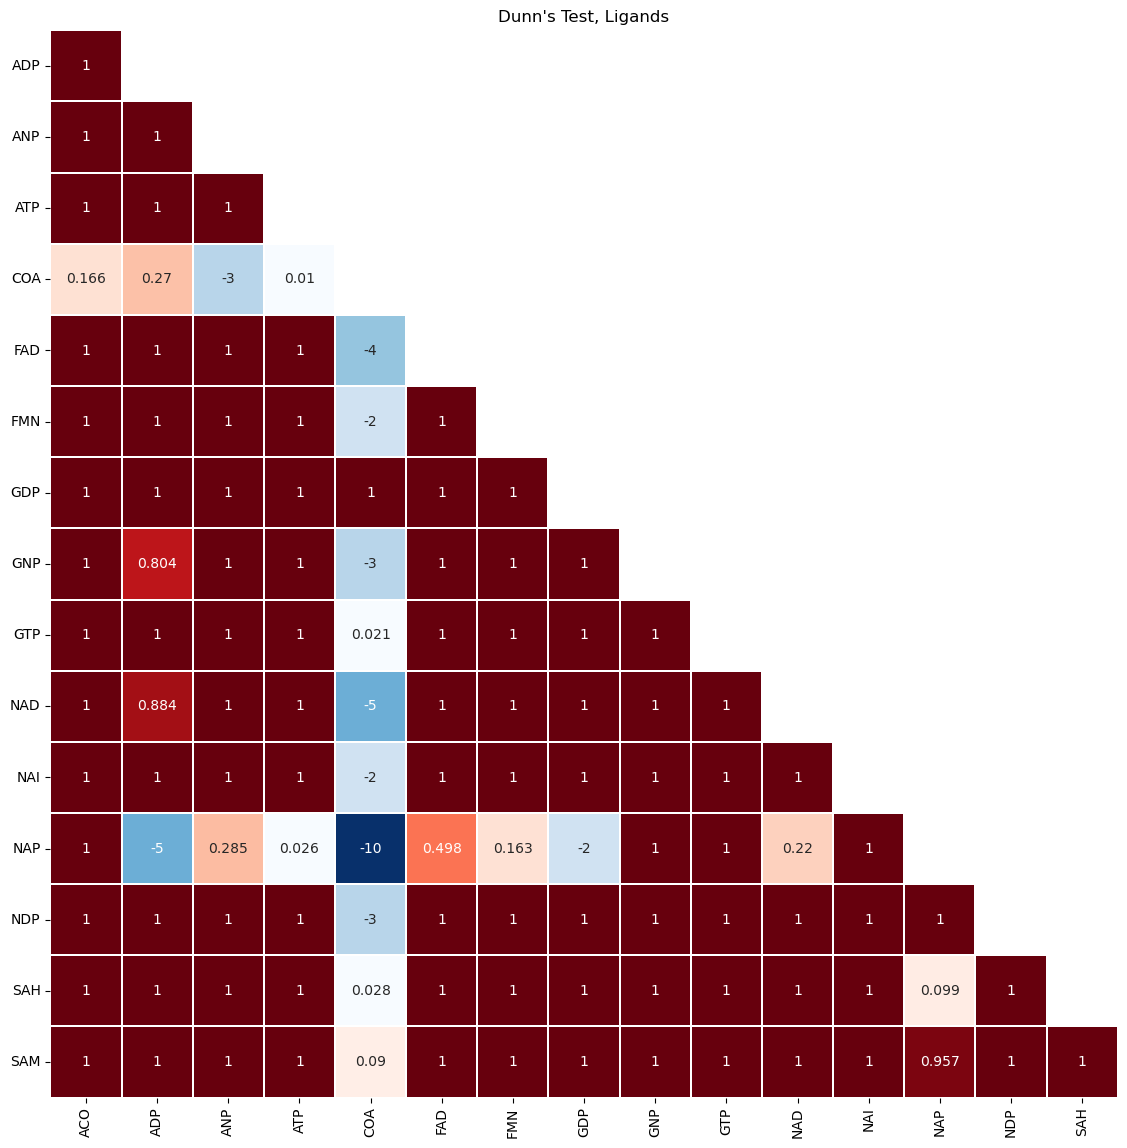

In [12]:
kruskal_table = pd.DataFrame(
    [{'classification': key, 'groups': value['n'], 'statistics': value['kruskal']['H'], 'p-value': value['kruskal']['p']} for key, value in combined_results.items()]
)
display(kruskal_table)
# print(kruskal_table.to_latex(caption='caption', label='label', float_format='%.4g'))

u.dunns_heatmap(combined_results['scope_class_desc'], "Dunn's Test, SCOPe Classes", 'Images/dunn_scope.pdf')
u.dunns_heatmap(combined_results['ec_class_desc'], "Dunn's Test, EC Classes", 'Images/dunn_ec.pdf')
u.dunns_heatmap(combined_results['size_class'], "Dunn's Test, Size Classes", 'Images/dunn_size.pdf')
u.dunns_heatmap(combined_results['organism'], "Dunn's Test, Organisms", 'Images/dunn_org.pdf')
u.dunns_heatmap(combined_results['reign'], "Dunn's Test, Reigns", 'Images/dunn_reign.pdf')
u.dunns_heatmap(combined_results['ligand'], "Dunn's Test, Ligands", 'Images/dunn_ligand.pdf')

## 4.9 Analyse Pairwise and Combine

- Combine Dunn and Cliff's deltas
- Keep track of significance
- Count Win/Lose events
- Apply linear regression -> latent factors -> rating

In [13]:
for group in GROUPS:
    result = u.analyze_pairs(
        combined_results[group],
        alpha=0.05,
        min_abs_delta=0.15
    )
    combined_results[group].update(result)

In [14]:
all_deltas = []
table_groups = []
table_classif = []

# Better names for classes and ligands (just for esthetic purpose)
CLASSIFICATION = {'scope_class': 'SCOPe', 'scope_class_desc': 'SCOPe', 'ec_class': 'EC', 'ec_class_desc': 'EC',
                  'reign': 'Reign', 'organism': 'Species', 'ligand': 'Ligand', 'size_class': 'Size'}
LIGANDS = {'NAP': 'NADP', 'NAI': 'NADH', 'GNP': 'Guanylyl imidodiphosphate', 'FAD': 'FAD', 'GTP': 'GTP', 'FMN': 'Vitamin B2 (riboflavin-5-phosphate)',
           'NAD': 'NAD', 'NDP': 'NADPH', 'ACO': 'Acetyl coenzyme-A', 'SAM': 'S-Adenosylmethionine', 'SAH': 'S-Adenosylhomocysteine',
           'ANP': 'Phosphoaminophosphonic acid-adenylate ester', 'ATP': 'ATP', 'ADP': 'ADP', 'GDP': 'GDP', 'COA': 'Coenzyme A'}

for group in GROUPS:

    # Sort by deltas
    pairs = combined_results[group]['pairs']
    pairs['order'] = pairs['Delta'].abs()
    all_deltas.append(pairs.loc[pairs['significant']].sort_values(by='order', ascending=False).drop(columns=['order']))

    # Switch to nice names
    class_name = CLASSIFICATION[group]
    if  class_name == 'Ligand':
        all_deltas[-1]['A'] = all_deltas[-1]['A'].map(LIGANDS)
        all_deltas[-1]['B'] = all_deltas[-1]['B'].map(LIGANDS)
    all_deltas[-1]['Type'] = class_name


    sizes = combined_results[group]['group_size']
    metrics = combined_results[group]['group_metric']
    counts = combined_results[group]['counts']
    rating = combined_results[group]['rating']

    table_classif.append({'Classification': group,
                          'N Groups': combined_results[group]["n"],
                          'Cycles': len(combined_results[group]["cycles"]),
                          'R-value': combined_results[group]["rating_corr"]})

    for g, _ in sorted(rating.items(), key=lambda x: x[1], reverse=True):
        table_groups.append({'Type': CLASSIFICATION[group],
                             'Group': g.replace("\n", " ") if class_name != 'Ligand' else LIGANDS[g],
                             'Latent Score': rating[g], 'F1': metrics[g],
                             'Win/Lose': counts[g], 'N': sizes[g]})


Significant Comparisons:

In [15]:
all_deltas = pd.concat(all_deltas, ignore_index=True)
all_deltas = all_deltas.loc[all_deltas['amplitude'] != 'negligible']
all_deltas = all_deltas[['Type', *[c for c in all_deltas.columns if c not in  ['Type', 'significant', 'abs_delta']]]]
display(all_deltas)
# print(all_deltas.to_latex(index=False, caption='caption', label='label', float_format='%.3g'))

,Type,A,B,p_value,Delta,amplitude
0,SCOPe,Helices + Sheets\n(segregated),Membrane Proteins,1.560779e-22,0.668527,very large
1,SCOPe,Artifacts,Membrane Proteins,1.234174e-16,0.628434,very large
2,SCOPe,Beta-Sheets,Membrane Proteins,9.564018e-12,0.597709,large
3,SCOPe,Helices + Sheets\n(segregated),Small \nUnconventional,2.177972e-08,0.525345,large
4,SCOPe,Alpha-Helices,Membrane Proteins,2.288946e-09,0.516304,large
5,SCOPe,Helices + Sheets\n(segregated),Multi-Domain,3.094442e-31,0.495532,large
6,SCOPe,Helices + Sheets\n(interleaved),Membrane Proteins,1.534779e-08,0.484263,large
7,SCOPe,Artifacts,Small \nUnconventional,6.384234e-06,0.478155,large
8,SCOPe,Beta-Sheets,Small \nUnconventional,8.360459e-04,0.445524,medium
9,SCOPe,Artifacts,Multi-Domain,3.063803e-19,0.431140,medium


Quality of Linear Regression by Grouping:

In [16]:
table_classif = pd.DataFrame(table_classif)
display(table_classif)
# print(table_classif.to_latex(index=False, caption='caption', label='label', float_format='%.5g'))

,Classification,N Groups,Cycles,R-value
0,scope_class_desc,8,0,0.996338
1,ec_class_desc,6,0,0.999826
2,size_class,8,0,0.978063
3,reign,4,0,1.000000
4,organism,18,0,0.999896
5,ligand,16,0,0.999852


The final table with Order of Classes:

In [18]:
table_groups = pd.DataFrame(table_groups)
display(table_groups)
# print(table_groups.to_latex(index=False, caption='caption', label='label', float_format='%.3g'))

,Type,Group,Latent Score,F1,Win/Lose,N
0,SCOPe,Helices + Sheets (segregated),0.314,0.494727,6,2087
1,SCOPe,Artifacts,0.238,0.467136,5,830
2,SCOPe,Beta-Sheets,0.165,0.442799,2,685
3,SCOPe,Alpha-Helices,0.090,0.419415,1,552
4,SCOPe,Helices + Sheets (interleaved),0.052,0.406079,1,2268
5,SCOPe,Multi-Domain,-0.201,0.308458,-5,182
6,SCOPe,Small Unconventional,-0.249,0.304482,-5,38
7,SCOPe,Membrane Proteins,-0.407,0.233281,-5,65
8,EC,Transferases,0.203,0.463950,4,2835
9,EC,Hydrolases,0.108,0.428385,3,1437
